# Fraud detection as a decision, not a classification (v2)

**Version 1** (January 2024) trained a Random Forest on the ULB credit-card dataset and reported
precision 0.974, recall 0.765 and MCC 0.863 on a random 20% test split, with the honest caveat that
about one fraud in four slipped through.

This notebook asks three harder questions:

1. **Do those numbers survive** a test that respects time and removes duplicate rows?
2. **How sure are we**, given that the test set holds only about a hundred frauds?
3. **What should the bank actually do?** A fraud team does not want "probability above 0.5"; it wants
   to review the transactions where the expected loss exceeds the cost of looking.

**Plan**
1. The data, its duplicates and its two days
2. Reproducing v1, with uncertainty
3. An honest test: deduplicated, split by time
4. Ranking quality: which model, and how sure?
5. From scores to probabilities: calibration
6. The decision: flag when probability x amount > review cost
7. What gets missed
8. Conclusions and limits

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from scipy.stats import beta
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score, matthews_corrcoef, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 20261007
R = {}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, WARM, GREY = "#1F3A5F", "#2A9D8F", "#C8553D", "#8A8A8A"


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")


def clopper_pearson(k, n, a=0.05):
    lo = beta.ppf(a / 2, k, n - k + 1) if k > 0 else 0.0
    hi = beta.ppf(1 - a / 2, k + 1, n - k) if k < n else 1.0
    return float(lo), float(hi)

## 1. The data, its duplicates and its two days

284,807 card transactions by European cardholders over two days in September 2013, released by the
Machine Learning Group of ULB (Dal Pozzolo et al. 2015). For confidentiality, 28 features are
principal components (V1 to V28) of undisclosed originals; only `Time` (seconds since the first
transaction) and `Amount` (euros) are raw. `scripts/get_data.py` fetches the file and checks its
SHA-256.

284,807 transactions over 48.0 hours; 492 frauds (0.173%)
1,081 exact duplicate rows (19 frauds among them)
fraud value €60,128; median fraud €9.25; 130 frauds above €100 carry 88.3% of the value; 27 frauds are for €0


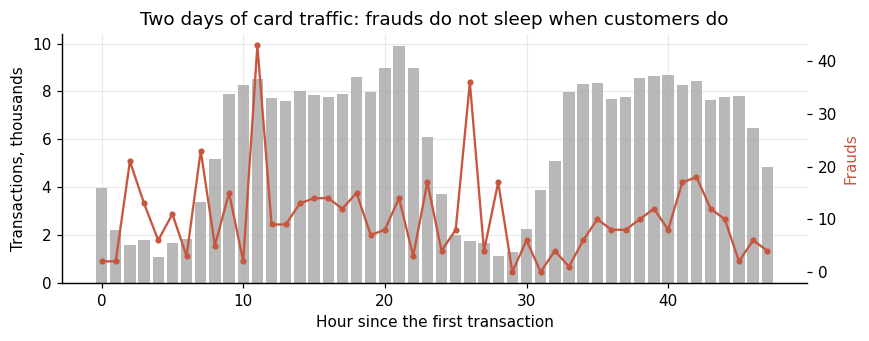

In [2]:
data = pd.read_csv(ROOT / "data" / "creditcard.csv")
R["rows"], R["frauds"] = len(data), int(data["Class"].sum())
R["fraud_rate"] = float(data["Class"].mean())
R["duplicate_rows"] = int(data.duplicated().sum())
R["duplicate_frauds"] = int(data[data.duplicated()]["Class"].sum())
R["hours"] = float(data["Time"].max() / 3600)
fr = data[data["Class"] == 1]
R["fraud_euros"] = float(fr["Amount"].sum())
R["fraud_median_amount"] = float(fr["Amount"].median())
R["fraud_over100_n"] = int((fr["Amount"] > 100).sum())
R["fraud_over100_value_share"] = float(fr.loc[fr["Amount"] > 100, "Amount"].sum() / R["fraud_euros"])
R["fraud_zero_amount"] = int((fr["Amount"] == 0).sum())
print(f"{R['rows']:,} transactions over {R['hours']:.1f} hours; {R['frauds']} frauds ({R['fraud_rate']:.3%})")
print(f"{R['duplicate_rows']:,} exact duplicate rows ({R['duplicate_frauds']} frauds among them)")
print(f"fraud value €{R['fraud_euros']:,.0f}; median fraud €{R['fraud_median_amount']:.2f}; "
      f"{R['fraud_over100_n']} frauds above €100 carry {R['fraud_over100_value_share']:.1%} of the value; "
      f"{R['fraud_zero_amount']} frauds are for €0")

hours = data.assign(h=(data["Time"] // 3600).astype(int)).groupby("h").agg(n=("Class", "size"), frauds=("Class", "sum"))
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(hours.index, hours["n"] / 1000, color=GREY, alpha=0.6, label="transactions (thousands)")
ax2 = ax.twinx()
ax2.plot(hours.index, hours["frauds"], color=WARM, marker="o", ms=3, label="frauds")
ax2.grid(False)
ax.set_xlabel("Hour since the first transaction")
ax.set_ylabel("Transactions, thousands")
ax2.set_ylabel("Frauds", color=WARM)
ax.set_title("Two days of card traffic: frauds do not sleep when customers do")
save(fig, "hourly.png")

Two facts shape everything below. Fraud money is concentrated: the median fraud is €9.25, but the 130
frauds above €100 carry 88.3% of the €60,128 stolen, and 27 frauds are for €0 (typically card tests).
And the dataset contains 1,081 exact duplicate rows, 19 of them frauds.

## 2. Reproducing v1, with uncertainty

v1 used a default Random Forest on a random 80/20 split (`random_state=42`) without fixing the forest's
own seed, so its exact numbers cannot be regenerated; a fixed seed is used here.

In [3]:
X, y = data.drop(columns="Class"), data["Class"].to_numpy()
idx_tr, idx_te = train_test_split(np.arange(len(data)), test_size=0.2, random_state=42)
rf_v1 = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1).fit(X.iloc[idx_tr], y[idx_tr])
p_v1 = rf_v1.predict_proba(X.iloc[idx_te])[:, 1]
yp = (p_v1 >= 0.5).astype(int)
yt = y[idx_te]
tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
R["v1_repro"] = {"precision": precision_score(yt, yp), "recall": recall_score(yt, yp), "f1": f1_score(yt, yp),
                 "mcc": matthews_corrcoef(yt, yp), "test_frauds": int(yt.sum()), "tp": int(tp), "fp": int(fp), "fn": int(fn)}
R["v1_recall_ci"] = clopper_pearson(tp, tp + fn)
R["v1_precision_ci"] = clopper_pearson(tp, tp + fp)
print({k: round(v, 3) if isinstance(v, float) else v for k, v in R["v1_repro"].items()})
print(f"recall {tp}/{tp + fn}: 95% interval {R['v1_recall_ci'][0]:.3f} to {R['v1_recall_ci'][1]:.3f}")
print(f"precision {tp}/{tp + fp}: 95% interval {R['v1_precision_ci'][0]:.3f} to {R['v1_precision_ci'][1]:.3f}")
key = pd.util.hash_pandas_object(X, index=False)
seen = key.iloc[idx_te].isin(set(key.iloc[idx_tr])).to_numpy()
R["v1_test_rows_with_twin_in_train"], R["v1_test_frauds_with_twin"] = int(seen.sum()), int(yt[seen].sum())
print(f"test rows with an identical row in training: {seen.sum()}, of which frauds: {yt[seen].sum()}")

{'precision': 0.963, 'recall': 0.786, 'f1': 0.865, 'mcc': np.float64(0.869), 'test_frauds': 98, 'tp': 77, 'fp': 3, 'fn': 21}
recall 77/98: 95% interval 0.691 to 0.862
precision 77/80: 95% interval 0.894 to 0.992
test rows with an identical row in training: 325, of which frauds: 5


With a fixed seed, v1's design gives precision 0.963, recall 0.786 and MCC 0.869, close to its published
0.974, 0.765 and 0.863: the difference is the forest's randomness. The more important number is the
interval. The test set held 98 frauds, so recall is known only to lie somewhere between 0.69 and 0.86;
a claim of "0.765" is precise to the third decimal about a quantity known to about plus or minus 0.09.
And 5 of those 98 test frauds had an identical twin in the training set, so the model had already seen
them.

## 3. An honest test: deduplicated, split by time

- **Duplicates** are dropped first (keeping the first copy), so no test row has a twin in training.
- **Time.** A deployed model scores transactions that happen after it was trained. Train on the first
  24 hours; use hours 24 to 36 to calibrate probabilities and choose decision rules; test once on the
  last 12 hours.
- **Features.** V1 to V28, log(1 + amount) and the hour of day (as sine and cosine). Raw `Time` is
  dropped: in a time split the test values lie outside anything seen in training.

In [4]:
d = data.drop_duplicates().copy()
d["hour"] = (d["Time"] % 86400) / 3600
d["hour_sin"], d["hour_cos"] = np.sin(2 * np.pi * d["hour"] / 24), np.cos(2 * np.pi * d["hour"] / 24)
d["log_amount"] = np.log1p(d["Amount"])
FEATS = [f"V{i}" for i in range(1, 29)] + ["log_amount", "hour_sin", "hour_cos"]
t = d["Time"] / 3600
train, valid, test = d[t < 24], d[(t >= 24) & (t < 36)], d[t >= 36]
for name, part in (("train", train), ("valid", valid), ("test", test)):
    R[f"{name}_rows"], R[f"{name}_frauds"] = len(part), int(part["Class"].sum())
    print(f"{name}: {len(part):,} transactions, {int(part['Class'].sum())} frauds, €{part.loc[part['Class'] == 1, 'Amount'].sum():,.0f} of fraud")

train: 144,236 transactions, 272 frauds, €32,469 of fraud
valid: 47,292 transactions, 87 frauds, €9,711 of fraud
test: 92,198 transactions, 114 frauds, €16,412 of fraud


The test window (the last 12 hours) holds 114 frauds worth €16,412. Small samples are the nature of
fraud data; every comparison below carries its uncertainty.

## 4. Ranking quality: which model, and how sure?

With 0.17% fraud, accuracy is meaningless and even ROC-AUC flatters (it rewards ranking millions of
easy legitimate transactions correctly). The headline metric is **average precision** (area under the
precision-recall curve), whose no-skill value is the fraud rate itself. Four models, settings fixed in
advance: logistic regression, v1's Random Forest, gradient-boosted trees, and logistic regression on a
SMOTE-resampled training set (the most common "fix" for imbalance, included to test it).

In [5]:
Xtr, ytr = train[FEATS], train["Class"].to_numpy()
Xva, yva = valid[FEATS], valid["Class"].to_numpy()
Xte, yte = test[FEATS], test["Class"].to_numpy()
models = {
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1)),
    "random forest (v1)": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=SEED, n_jobs=-1),
    "boosted trees": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0,
                                                    random_state=SEED),
}
scores_va, scores_te = {}, {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    scores_va[name], scores_te[name] = m.predict_proba(Xva)[:, 1], m.predict_proba(Xte)[:, 1]
Xs, ys = SMOTE(random_state=SEED).fit_resample(Xtr, ytr)
sm = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1)).fit(Xs, ys)
scores_va["logistic + SMOTE"], scores_te["logistic + SMOTE"] = sm.predict_proba(Xva)[:, 1], sm.predict_proba(Xte)[:, 1]

rng = np.random.default_rng(SEED)
boot = {m: [] for m in scores_te}
for _ in range(2000):
    i = rng.integers(0, len(yte), len(yte))
    if yte[i].sum() == 0:
        continue
    for m, s in scores_te.items():
        boot[m].append(average_precision_score(yte[i], s[i]))
rows = []
for m, s in scores_te.items():
    lo, hi = np.percentile(boot[m], [2.5, 97.5])
    rows.append({"model": m, "average_precision": average_precision_score(yte, s), "ap_lo": lo, "ap_hi": hi,
                 "roc_auc": roc_auc_score(yte, s)})
rank = pd.DataFrame(rows).sort_values("average_precision", ascending=False)
rank.to_csv(ROOT / "results" / "ranking_quality.csv", index=False)
R["ranking"] = rank.set_index("model").round(4).to_dict(orient="index")
R["no_skill_ap"] = float(yte.mean())
print(rank.round(3).to_string(index=False))
print(f"no-skill average precision = fraud rate in the test window = {yte.mean():.4f}")
d_boot = np.array(boot["boosted trees"]) - np.array(boot["random forest (v1)"])
R["gb_minus_rf_ap_ci"] = [float(np.percentile(d_boot, 2.5)), float(np.percentile(d_boot, 97.5))]
print(f"boosted trees minus random forest, 95% interval: {R['gb_minus_rf_ap_ci'][0]:.3f} to {R['gb_minus_rf_ap_ci'][1]:.3f}")

             model  average_precision  ap_lo  ap_hi  roc_auc
random forest (v1)              0.760  0.682  0.830    0.963
     boosted trees              0.750  0.669  0.823    0.972
  logistic + SMOTE              0.702  0.614  0.782    0.965
          logistic              0.602  0.503  0.692    0.966
no-skill average precision = fraud rate in the test window = 0.0012
boosted trees minus random forest, 95% interval: -0.037 to 0.017


- **v1's model choice was sound.** On the honest test, the Random Forest ranks best (average precision
  0.760, interval 0.68 to 0.83), statistically tied with gradient-boosted trees (difference -0.04 to
  +0.02). Both are more than 600 times the no-skill level of 0.0012.
- **ROC-AUC hides the differences**: every model scores between 0.963 and 0.972, while average
  precision ranges from 0.60 to 0.76. On rare events, ROC-AUC mostly measures how well a model ranks
  the easy legitimate transactions.
- **SMOTE helped the linear model rank** (0.602 to 0.702), which is a fair result to report, but see
  the next section for what it does to probabilities.

fig, ax = plt.subplots(figsize=(6.4, 4))
for (m, s), c in zip(scores_te.items(), (ACCENT, INK, WARM, GREY)):
    pr, rc, _ = precision_recall_curve(yte, s)
    ax.plot(rc, pr, color=c, label=f"{m} (AP {average_precision_score(yte, s):.2f})")
ax.set(xlabel="Recall (share of frauds caught)", ylabel="Precision (share of alerts that are fraud)",
       title="Precision-recall on the last 12 hours")
ax.legend(frameon=False, fontsize=8)
save(fig, "precision_recall.png")

## 5. From scores to probabilities: calibration

A cost-based decision needs probabilities that mean what they say. Forest votes and SMOTE-trained
models are not probabilities. Each model is recalibrated with isotonic regression on the validation
window (hours 24 to 36) and checked on the test window.

In [6]:
cal_te = {}
rows = []
for m in scores_te:
    iso = IsotonicRegression(out_of_bounds="clip").fit(scores_va[m], yva)
    cal_te[m] = iso.predict(scores_te[m])
    rows.append({"model": m, "mean_raw_score": scores_te[m].mean(), "mean_calibrated": cal_te[m].mean(), "observed_rate": yte.mean(),
                 "flagged_at_0.5_raw": int((scores_te[m] >= 0.5).sum())})
calib = pd.DataFrame(rows)
print(calib.round(5).to_string(index=False))
R["calibration"] = calib.set_index("model").round(6).to_dict(orient="index")

             model  mean_raw_score  mean_calibrated  observed_rate  flagged_at_0.5_raw
          logistic         0.00180          0.00289        0.00124                  85
random forest (v1)         0.00274          0.00109        0.00124                 100
     boosted trees         0.00147          0.00135        0.00124                 120
  logistic + SMOTE         0.09008          0.00129        0.00124                4400


The SMOTE-trained model's scores average 0.090 when the true fraud rate is 0.0012: about 75 times too
high, because it was trained on a world where fraud is as common as legitimate spending. At the default
0.5 threshold it would flag 4,400 of 92,198 transactions. Isotonic recalibration on the validation window
brings every model's average back to the observed rate. Resampling can help ranking; it must never be
read as probability.

## 6. The decision: flag when probability x amount > review cost

Suppose reviewing an alert costs **c** euros of analyst time, and a fraud that is caught is fully
recovered while a missed one is lost. For transaction *i* with fraud probability $p_i$ and amount
$A_i$, reviewing it is worth it exactly when

$$p_i \, A_i > c,$$

because $p_i A_i$ is the expected loss avoided by looking. A fixed probability threshold ignores the
amount: it spends the same effort on a likely €1 card test as on a likely €1,000 fraud.

The cost of a policy on the test window is (missed fraud euros) + c x (alerts). Three policies are
compared for review costs of €1, €5, €10 and €25 (assumptions; the dataset carries no cost data):

- **v1 rule**: flag if the raw score is at least 0.5;
- **best fixed threshold**: the probability threshold that minimised cost on the validation window;
- **expected-loss rule**: flag if calibrated $p_i A_i > c$.

In [7]:
MODEL = "boosted trees" if R["ranking"]["boosted trees"]["average_precision"] >= R["ranking"]["random forest (v1)"]["average_precision"] else "random forest (v1)"
R["decision_model"] = MODEL
amt_va, amt_te = valid["Amount"].to_numpy(), test["Amount"].to_numpy()
iso = IsotonicRegression(out_of_bounds="clip").fit(scores_va[MODEL], yva)
p_va, p_te = iso.predict(scores_va[MODEL]), iso.predict(scores_te[MODEL])


def cost(flag, yv, amt, c):
    missed = amt[(yv == 1) & (~flag)].sum()
    return missed + c * flag.sum(), missed, int(flag.sum())


grid = np.unique(np.quantile(p_va, np.linspace(0.95, 1, 400)))
out = []
total_fraud_te = float(amt_te[yte == 1].sum())
for c in (1, 5, 10, 25):
    best_t = min(grid, key=lambda th: cost(p_va >= th, yva, amt_va, c)[0])
    pol = {"do nothing": np.zeros(len(yte), bool), "v1 rule (score >= 0.5)": scores_te[MODEL] >= 0.5,
           "best fixed threshold": p_te >= best_t, "expected-loss rule": p_te * amt_te > c}
    for name, flag in pol.items():
        tot, missed, alerts = cost(flag, yte, amt_te, c)
        caught_n = int(((yte == 1) & flag).sum())
        out.append({"review_cost": c, "policy": name, "total_cost": tot, "missed_euros": missed, "alerts": alerts,
                    "frauds_caught": caught_n, "fraud_euros_caught_share": 1 - missed / total_fraud_te,
                    "fraud_count_caught_share": caught_n / yte.sum()})
dec = pd.DataFrame(out)
dec.to_csv(ROOT / "results" / "decision_policies.csv", index=False)
R["decision"] = {f"c{r.review_cost}_{r.policy}": {"total_cost": float(r.total_cost), "missed": float(r.missed_euros), "alerts": int(r.alerts),
                                                   "euros_caught": float(r.fraud_euros_caught_share), "count_caught": float(r.fraud_count_caught_share)}
                 for r in dec.itertuples()}
R["test_fraud_euros"] = total_fraud_te
print(f"model: {MODEL}; fraud in the test window: {int(yte.sum())} transactions, €{total_fraud_te:,.0f}")
print(dec.round(3).to_string(index=False))

model: random forest (v1); fraud in the test window: 114 transactions, €16,412
 review_cost                 policy  total_cost  missed_euros  alerts  frauds_caught  fraud_euros_caught_share  fraud_count_caught_share
           1             do nothing    16411.64      16411.64       0              0                     0.000                     0.000
           1 v1 rule (score >= 0.5)     6053.73       5953.73     100             77                     0.637                     0.675
           1   best fixed threshold     4535.46       3973.46     562             96                     0.758                     0.842
           1     expected-loss rule     3415.83       2885.83     530             48                     0.824                     0.421
           5             do nothing    16411.64      16411.64       0              0                     0.000                     0.000
           5 v1 rule (score >= 0.5)     6453.73       5953.73     100             77               

**At a review cost of €5, the expected-loss rule lowers the cost of the last 12 hours from €6,454 (v1's
rule) to €4,679, a 27% reduction, with a similar number of alerts (112 against 100).** It does so by
catching 74.9% of the fraud *euros* instead of 63.7%, while catching only 35.1% of the frauds by
*count* against v1's 67.5%. It deliberately ignores small frauds that are not worth an analyst's time
and spends that time on large ones. The pattern holds at every review cost tested (€1 to €25).

Two honest notes. The "best fixed threshold", tuned on the validation window, does worse than v1's rule
at €25: with only 87 frauds to tune on, a threshold is easy to overfit, while the expected-loss rule
needs no tuning beyond calibration. And the rule's blind spot is deliberate: a €0 card test has no
expected loss, but it is often the probe before a real fraud.

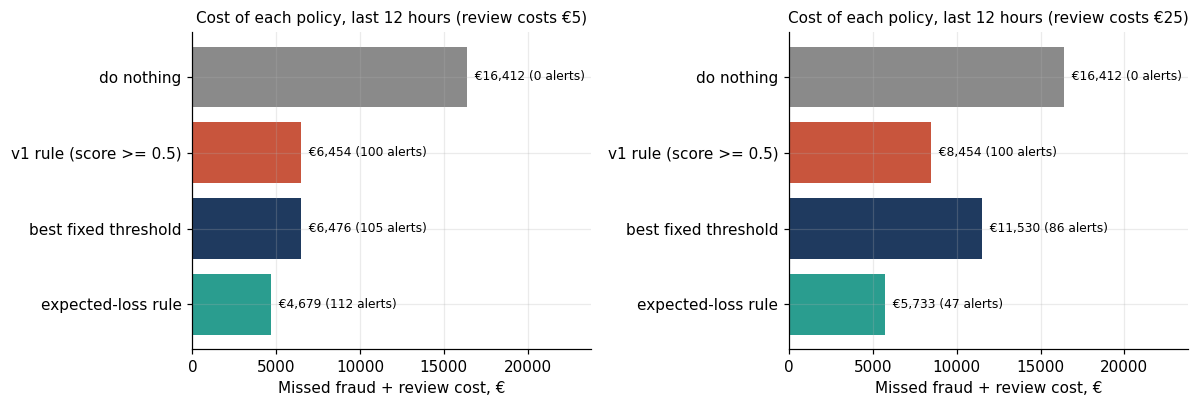

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, c in zip(axes, (5, 25)):
    sub = dec[dec["review_cost"] == c].set_index("policy")
    ax.barh(sub.index[::-1], sub["total_cost"][::-1], color=[ACCENT, INK, WARM, GREY])
    for i, (v, a) in enumerate(zip(sub["total_cost"][::-1], sub["alerts"][::-1])):
        ax.text(v, i, f"  €{v:,.0f} ({a} alerts)", va="center", fontsize=8)
    ax.set_title(f"Cost of each policy, last 12 hours (review costs €{c})", fontsize=10)
    ax.set_xlabel("Missed fraud + review cost, €")
    ax.set_xlim(0, sub["total_cost"].max() * 1.45)
save(fig, "policy_costs.png")

## 7. What gets missed

In [9]:
c = 5
flag = p_te * amt_te > c
fr_te = test[test["Class"] == 1].assign(caught=flag[yte == 1], p=p_te[yte == 1])
fr_te["amount_band"] = pd.cut(fr_te["Amount"], [-0.01, 0, 10, 100, 500, 10000], labels=["€0", "€0-10", "€10-100", "€100-500", "over €500"])
miss = fr_te.groupby("amount_band", observed=True).agg(frauds=("Amount", "size"), caught=("caught", "sum"), value=("Amount", "sum"))
print(miss.to_string())
R["missed_by_band_c5"] = miss.to_dict(orient="index")

             frauds  caught    value
amount_band                         
€0                9       0     0.00
€0-10            54       3   123.12
€10-100          18      12   836.10
€100-500         22      17  5524.84
over €500        11       8  9927.58


The rule lets through 60 of the 63 frauds of €10 or less (worth €123 together) and catches 25 of the 33
frauds over €100. The €0 card tests are worth flagging for a different reason (they predict the next
fraud), which a separate rule on card-testing patterns should handle; amount-based triage and
card-testing detection answer different questions.

## 8. Conclusions and limits

| v1 | v2 |
|---|---|
| Precision 0.974, recall 0.765 on a random split | Reproduced (0.963, 0.786 with a fixed seed); recall's 95% interval is 0.69 to 0.86, and 5 of 98 test frauds had a twin in training |
| Random Forest | Still the best ranker on a deduplicated, time-ordered test (average precision 0.760), tied with boosted trees |
| Threshold 0.5 | Flag when calibrated probability x amount exceeds the review cost: 27% lower cost at €5 per review, 74.9% of fraud euros caught instead of 63.7% |
| "Next steps: class weighting or resampling" | SMOTE helps a linear model rank but makes its scores 75 times too high; it is not a substitute for calibration |

**Limits.** Two days of data; the principal components V1 to V28 were computed by the data publisher
on the full two days, which a deployed system could not do (a leak this notebook cannot undo); the
review cost is an assumption shown as a range; caught frauds are assumed fully recovered; card-testing
patterns need their own rule.

In [10]:
(ROOT / "results" / "metrics.json").write_text(json.dumps(R, indent=1, default=float))
print(json.dumps({k: v for k, v in R.items() if not isinstance(v, dict)}, indent=1, default=float))

{
 "rows": 284807,
 "frauds": 492,
 "fraud_rate": 0.001727485630620034,
 "duplicate_rows": 1081,
 "duplicate_frauds": 19,
 "hours": 47.99777777777778,
 "fraud_euros": 60127.97,
 "fraud_median_amount": 9.25,
 "fraud_over100_n": 130,
 "fraud_over100_value_share": 0.8832613174866872,
 "fraud_zero_amount": 27,
 "v1_recall_ci": [
  0.6912866540638396,
  0.8621896314615041
 ],
 "v1_precision_ci": [
  0.8942980149834914,
  0.9921988127342833
 ],
 "v1_test_rows_with_twin_in_train": 325,
 "v1_test_frauds_with_twin": 5,
 "train_rows": 144236,
 "train_frauds": 272,
 "valid_rows": 47292,
 "valid_frauds": 87,
 "test_rows": 92198,
 "test_frauds": 114,
 "no_skill_ap": 0.0012364693377296687,
 "gb_minus_rf_ap_ci": [
  -0.036603065704225335,
  0.016658164295209697
 ],
 "decision_model": "random forest (v1)",
 "test_fraud_euros": 16411.64
}
